In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy import sparse
import math  
import sklearn.metrics 
from sklearn.metrics import mean_absolute_error
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline
from sklearn.preprocessing import StandardScaler
import pandas as pd

In [2]:
df = pd.read_csv("BBDD_100K/ratings.csv")

indice=list(df['userId'].unique())
columnas=list(df['movieId'].unique())
indice=sorted(indice)
columnas=sorted(columnas)
matriz_usuario_pelicula=pd.pivot_table(data=df,values='rating',index='userId',columns='movieId')
matriz_usuario_pelicula.head()


movieId,1,2,3,4,5,6,7,8,9,10,...,193565,193567,193571,193573,193579,193581,193583,193585,193587,193609
userId,,,,,,,,,,,,,,,,,,,,,
1,4.0,NaN,4.0,NaN,NaN,4.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
def normalizar_datos(matriz_escasez):
    # Creamos una copia de la matriz para evitar modificar el original
    matriz_escasez_copy = matriz_escasez.copy()
    
    # Inicializamos StandardScaler sin centrado en 0 debido a NaNs
    scaler = StandardScaler(with_mean=True, with_std=True)
    
    # Aplicamos la normalización solo en las columnas que tienen datos no NaN
    for user_id in matriz_escasez_copy.index:
        # Seleccionamos las calificaciones del usuario (excluyendo NaNs)
        user_ratings = matriz_escasez_copy.loc[user_id].dropna()
        if not user_ratings.empty:
            # Normalizamos las calificaciones de este usuario
            normalized_ratings = scaler.fit_transform(user_ratings.values.reshape(-1, 1)).flatten()
            # Colocamos los valores normalizados en la matriz original, manteniendo NaNs donde no hay calificaciones
            matriz_escasez_copy.loc[user_id, user_ratings.index] = normalized_ratings
    
    # Llenamos los NaNs con 0
    matriz_escasez_copy = matriz_escasez_copy.fillna(0)
    return matriz_escasez_copy

matriz_normalizada = normalizar_datos(matriz_usuario_pelicula)
matriz_normalizada.head(20)

movieId,1,2,3,4,5,6,7,8,9,10,...,193565,193567,193571,193573,193579,193581,193583,193585,193587,193609
userId,,,,,,,,,,,,,,,,,,,,,
1,-0.458937,0.000000,-0.458937,0.000000,0.000000,-0.458937,0.000000,0.000000,0.0,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,0.371391,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6,0.000000,0.596225,1.773677,-0.581226,1.773677,0.596225,0.596225,-0.581226,0.0,-0.581226,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7,0.958138,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8,0.000000,0.442374,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,-1.636784,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [4]:
def reescalar_predicciones(predicciones_normalizadas, matriz_usuario_pelicula, min_rating=0.5, max_rating=5.0):
    # Calculamos la media y desviación estándar de cada usuario ignorando los NaNs originales
    medias_usuarios = matriz_usuario_pelicula.mean(axis=1, skipna=True)
    desviaciones_usuarios = matriz_usuario_pelicula.std(axis=1, skipna=True)
    
    # Aplicamos la transformación inversa sólo donde había datos originales
    predicciones_reescaladas = predicciones_normalizadas.mul(desviaciones_usuarios, axis=0).add(medias_usuarios, axis=0)
    predicciones_reescaladas = predicciones_reescaladas.where(~matriz_usuario_pelicula.isna(), np.nan)
    predicciones_reescaladas = predicciones_reescaladas.round()
    predicciones_reescaladas = predicciones_reescaladas.clip(lower=min_rating, upper=max_rating)
    
    return predicciones_reescaladas



In [5]:
matriz_reescalada_original = reescalar_predicciones(matriz_normalizada, matriz_usuario_pelicula)
matriz_reescalada_original.head()

movieId,1,2,3,4,5,6,7,8,9,10,...,193565,193567,193571,193573,193579,193581,193583,193585,193587,193609
userId,,,,,,,,,,,,,,,,,,,,,
1,4.0,NaN,4.0,NaN,NaN,4.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Determinar la mejor K

Método del Codo: Evalúa la inercia (suma de las distancias cuadradas de las muestras a su centroide más cercano).

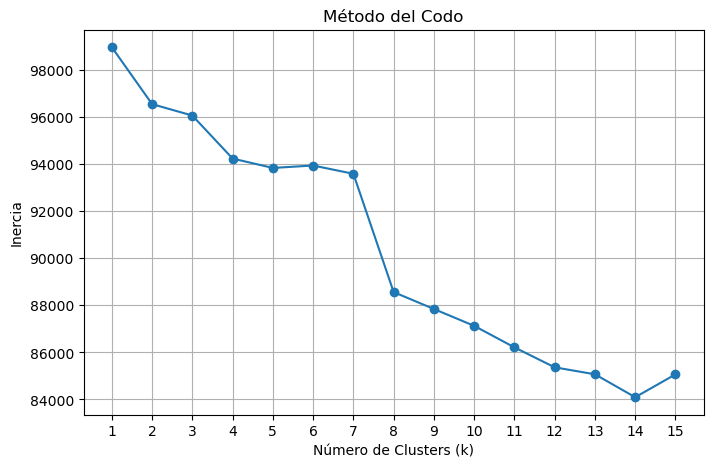

In [6]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

def metodo_del_codo(matriz, max_k=15):
    inercia = []
    for k in range(1, max_k + 1):
        kmeans = KMeans(n_clusters=k, random_state=42)
        kmeans.fit(matriz)
        inercia.append(kmeans.inertia_)
    
    # Graficar la inercia para ver el "codo"
    plt.figure(figsize=(8, 5))
    plt.plot(range(1, max_k + 1), inercia, marker='o')
    plt.title('Método del Codo')
    plt.xlabel('Número de Clusters (k)')
    plt.ylabel('Inercia')
    plt.xticks(range(1, max_k + 1))
    plt.grid(True)
    plt.show()

# Ejecuta el método del codo con la matriz normalizada
metodo_del_codo(matriz_normalizada)


Observando la curva, parece que el "codo" ocurre alrededor de k = 8, donde la disminución de la inercia se vuelve menos pronunciada. Esto sugiere que 8 clústeres podría ser un valor razonable.

Silhouette Score: Mide qué tan cerca están los puntos de su clúster en comparación con otros clústeres.\
Es otra forma de mirar la k óptima, pero en este caso estamos teniendo en cuenta las distáncias, mientras que el método del Codo no se tienen en cuenta las distancias

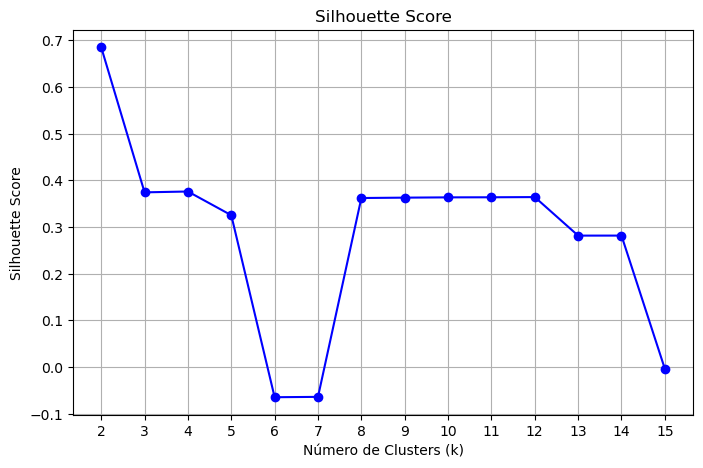

In [7]:
from sklearn.metrics import silhouette_score

def calcular_silhouette_score(matriz, min_k=2, max_k=15):
    """Calcula y guarda el Silhouette Score para diferentes valores de k."""
    silhouette_scores = []
    for k in range(min_k, max_k + 1):
        kmeans = KMeans(n_clusters=k, random_state=42)
        labels = kmeans.fit_predict(matriz)
        score = silhouette_score(matriz, labels)
        silhouette_scores.append(score)
    
    # Graficar el Silhouette Score
    plt.figure(figsize=(8, 5))
    plt.plot(range(min_k, max_k + 1), silhouette_scores, marker='o', color='blue')
    plt.title('Silhouette Score')
    plt.xlabel('Número de Clusters (k)')
    plt.ylabel('Silhouette Score')
    plt.xticks(range(min_k, max_k + 1))
    plt.grid(True)
    plt.show()

# Ejecución: guarda la lista de Silhouette Scores
calcular_silhouette_score(matriz_normalizada)


k=2 tiene el Silhouette Score más alto (0.6850), lo cual es típico porque agrupar todo en 2 clústeres maximiza la cohesión interna.

Sin embargo, después de k=2, el puntaje es más estable y ligeramente mejor en k=12 (0.3641), aunque las diferencias en los valores para k=8 a 12 son mínimas.

La elección entre k=2 (alta separación con menor granularidad) y k=12 (balance razonable) dependerá del nivel de detalle que se busque en las recomendaciones

Puesto que Tanto el método del codo como el de Silhouette coinden ambos en que K=8 es un buen candidato, `nos quedaremos con 8 clusters.`

## IMPLEMENTACIÓN KMEANS

Lo primero que tenemos que hacer para implementar Kmeans es decidir que tipo de agrupación de clusteres vamos a realizar, si clusteres de usuarios similares, o clusteres de películas. En este caso como disponemos de menos usuarios que películas los clusteres serán de usuarios, esto se hace así porque 610 usuarios son mucho mas manejables que 9270 películas, Kmeans será mas eficiente y rápido con menos filas (usuarios) en la matriz.



Implementaré Kmeans con la distancia del Coseno, puesto que esta distancia no viene directamente con el Kmenas habrá que calcular la distancia de coseno a parte.

In [8]:
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np
from sklearn.cluster import KMeans
import os


In [9]:
def calcular_distancia_coseno(matriz_normalizada, archivo_salida='distancia_coseno.npy'):
    """
    Calcula la matriz de distancia coseno si no existe en el archivo especificado,
    y la guarda en ese archivo. Si el archivo ya existe, carga la matriz desde el archivo.

    Args:
        matriz_normalizada (DataFrame): La matriz de usuarios vs películas normalizada.
        archivo_salida (str): Nombre del archivo donde guardar o cargar la matriz de distancia coseno.

    Returns:
        np.array: Matriz de distancia coseno.
    """
    if os.path.exists(archivo_salida):
        # Cargar desde archivo si existe
        distancia_coseno = np.load(archivo_salida)
    else:
        # Calcular la similitud coseno y la distancia si el archivo no existe
        similitud_coseno = cosine_similarity(matriz_normalizada)
        distancia_coseno = 1 - similitud_coseno  # Convertir la similitud coseno en distancia coseno
        
        # Guardar la matriz de distancia coseno en el archivo
        np.save(archivo_salida, distancia_coseno)
        print(f"Matriz de distancia coseno guardada en '{archivo_salida}'")

    return distancia_coseno


In [10]:
distancia_coseno = calcular_distancia_coseno(matriz_normalizada)

In [11]:
# Usaremos la matriz de similitud como entrada a KMeans
modelo_kmeans = KMeans(n_clusters=8, random_state=42)
# Aplicar KMeans directamente sobre la matriz de distancia
clusters_usuarios = modelo_kmeans.fit_predict(distancia_coseno)
# Agregar los clusters a la matriz original

## CALIDAD DEL CLÚSTER

Ahora miraremos que la distribución de los clústeres sea correcta

In [12]:
# Contar el número de usuarios por cluster
distribucion_clusters = pd.DataFrame(clusters_usuarios, columns=['Cluster'])
print(distribucion_clusters['Cluster'].value_counts())


Cluster
5    118
6    105
3     89
1     88
7     88
2     60
0     40
4     22
Name: count, dtype: int64


Los clústeres parecen prometedores, pero vamos a ver las películas promedio más calificadas por los usuarios de cada clúster para ver si existen patrones específicos

In [13]:
# Agregar los clusters a la matriz normalizada
matriz_normalizada['cluster'] = clusters_usuarios

# Calcular la calificación promedio por cluster
peliculas_por_cluster = matriz_normalizada.groupby('cluster').mean()

# Mostrar las 5 películas más populares por cluster
for cluster in range(8):
    print(f"\nPelículas más populares en el cluster {cluster}:")
    print(peliculas_por_cluster.loc[cluster].sort_values(ascending=False).head(5))



Películas más populares en el cluster 0:
movieId
110    0.994783
318    0.854707
356    0.816204
457    0.785685
150    0.644245
Name: 0, dtype: float64

Películas más populares en el cluster 1:
movieId
260     0.825781
2571    0.561195
1196    0.535617
4993    0.501628
1198    0.498329
Name: 1, dtype: float64

Películas más populares en el cluster 2:
movieId
296    0.689634
593    0.655096
318    0.632916
356    0.624627
50     0.466312
Name: 2, dtype: float64

Películas más populares en el cluster 3:
movieId
60069    0.108852
2571     0.102586
4896     0.100946
8368     0.100171
5816     0.100102
Name: 3, dtype: float64

Películas más populares en el cluster 4:
movieId
593    1.314724
296    1.256327
318    1.143587
527    0.908327
356    0.848707
Name: 4, dtype: float64

Películas más populares en el cluster 5:
movieId
296     0.386359
858     0.376550
2858    0.284068
1193    0.262993
608     0.261445
Name: 5, dtype: float64

Películas más populares en el cluster 6:
movieId
356   

 La lista de películas más populares dentro de cada cluster refleja que los grupos tienen preferencias diferenciadas. Esto es un indicador de que el clustering está capturando patrones útiles para la personalización.

 Por ejemplo la película con el id 318 que correponde a "Shawshank Redemption, The (1994) con el genero de Crimen/Drama" demuestra ser puntuada de manera muy diferente dependiendo del clúster, esto da a entender que dependiendo del clúster también existe una preferencia u otra sobre los diferentes géneros que hay.

 A continuación vamos a visualizar esos clústeres:

##  VISUALIZACIÓN

In [14]:
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from scipy.spatial import ConvexHull
import numpy as np



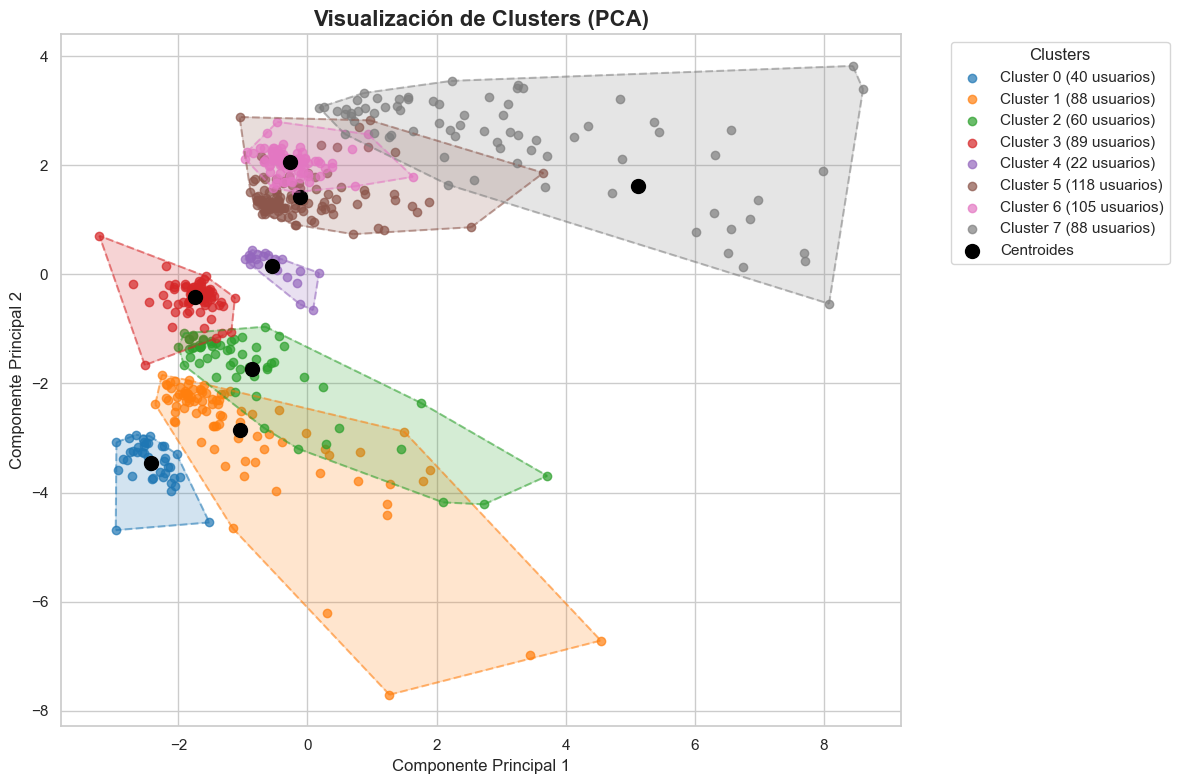

In [18]:


# Reducir la dimensionalidad a 2 componentes principales
matriz_normalizada_visualizacion = matriz_normalizada.copy()
matriz_normalizada_visualizacion.columns = matriz_normalizada_visualizacion.columns.astype(str)

# Aplicar PCA
pca = PCA(n_components=2)
matriz_reducida = pca.fit_transform(matriz_normalizada_visualizacion)

# Crear un DataFrame con los clusters
df_clusters = pd.DataFrame({
    'Componente_1': matriz_reducida[:, 0],
    'Componente_2': matriz_reducida[:, 1],
    'Cluster': clusters_usuarios
})

# Configurar los umbrales para el zoom
umbral_x_min = -10
umbral_x_max = 10
umbral_y_min = -10
umbral_y_max = 10

# Filtrar los puntos que se encuentran dentro de los umbrales para la visualización
df_clusters_filtrado = df_clusters[
    (df_clusters['Componente_1'] >= umbral_x_min) & 
    (df_clusters['Componente_1'] <= umbral_x_max) & 
    (df_clusters['Componente_2'] >= umbral_y_min) & 
    (df_clusters['Componente_2'] <= umbral_y_max)
]

# Configurar estilo de gráfico
sns.set(style="whitegrid")
plt.figure(figsize=(12, 8))

# Colores para los clusters
colores = sns.color_palette("tab10", len(df_clusters['Cluster'].unique()))

# Dibujar contornos y graficar puntos
for cluster, color in zip(sorted(df_clusters['Cluster'].unique()), colores):
    # Usamos df_clusters_filtrado solo para los puntos visibles
    datos_cluster_filtrado = df_clusters_filtrado[df_clusters_filtrado['Cluster'] == cluster]
    puntos = datos_cluster_filtrado[['Componente_1', 'Componente_2']].values
    
    # Dibujar Convex Hull si hay suficientes puntos
    if len(puntos) > 2:  # ConvexHull requiere al menos 3 puntos
        hull = ConvexHull(puntos)
        for simplex in hull.simplices:
            plt.plot(puntos[simplex, 0], puntos[simplex, 1], c=color, alpha=0.5, linestyle='--')
        plt.fill(puntos[hull.vertices, 0], puntos[hull.vertices, 1], color=color, alpha=0.2)
    
    # Graficar puntos del cluster (solo los que están en el área filtrada para el "zoom")
    plt.scatter(
        datos_cluster_filtrado['Componente_1'], 
        datos_cluster_filtrado['Componente_2'], 
        label=f'Cluster {cluster} ({len(df_clusters[df_clusters["Cluster"] == cluster])} usuarios)', 
        alpha=0.7, 
        color=color
    )

# Centroides como puntos pequeños
centroides = df_clusters.groupby('Cluster')[['Componente_1', 'Componente_2']].mean()
plt.scatter(
    centroides['Componente_1'], 
    centroides['Componente_2'], 
    s=100, 
    c='black', 
    marker='o', 
    label='Centroides'
)

# Ajustar título, etiquetas y leyenda
plt.title('Visualización de Clusters (PCA)', fontsize=16, fontweight='bold')
plt.xlabel('Componente Principal 1', fontsize=12)
plt.ylabel('Componente Principal 2', fontsize=12)
plt.legend(title='Clusters', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

# Mostrar gráfico
plt.show()


En esta gráfica, los puntos representan a los usuarios proyectados en un espacio de 2 dimensiones utilizando los Componentes Principales. Los componentes principales son combinaciones lineales de las calificaciones originales que capturan la mayor parte de la variabilidad en los datos.

El Primer Componente Principal (PC1) explica la mayor cantidad de variación en las calificaciones, mientras que el Segundo Componente Principal (PC2) captura la siguiente mayor variabilidad, siendo ambos ortogonales entre sí. Los clusters muestran agrupaciones de usuarios con patrones similares de calificación, la distancia que existe entre estos a parte de por las calificaciones promedio puede ser debida a la preferencia de géneros

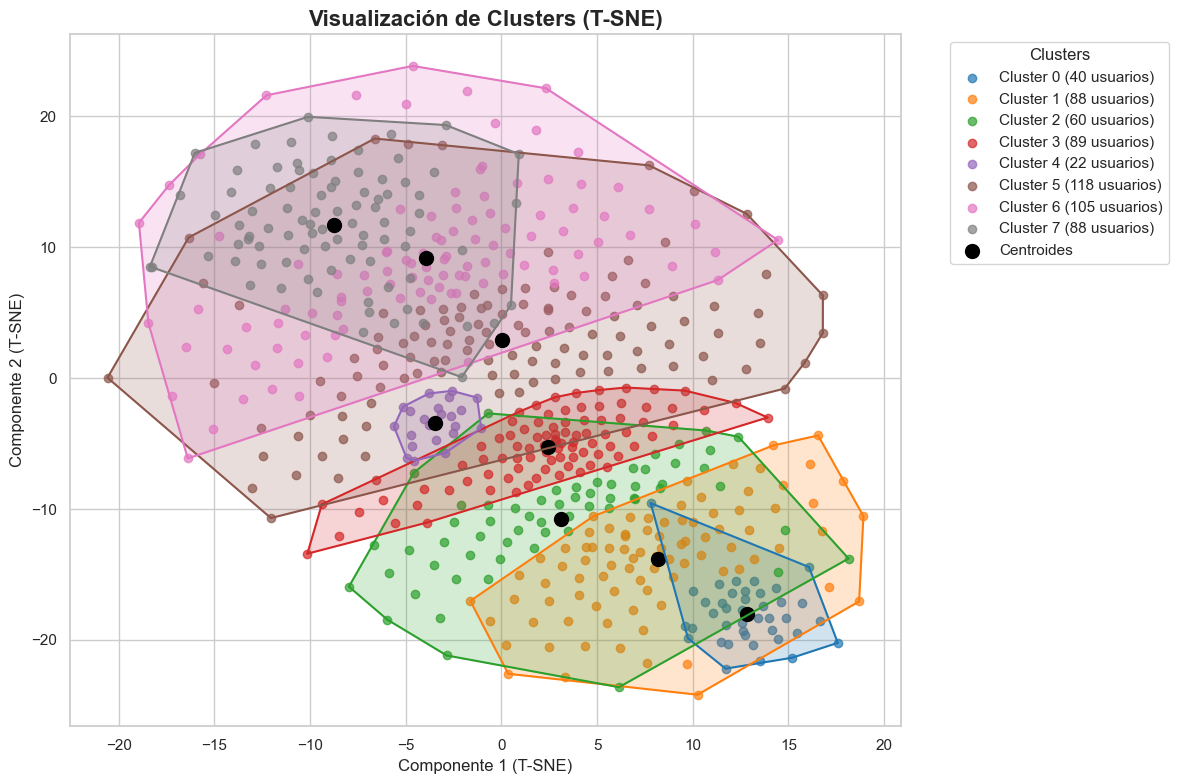

In [16]:
# Configurar T-SNE
tsne = TSNE(n_components=2, random_state=42, perplexity=30)

# Reducir la dimensionalidad con T-SNE
matriz_reducida = tsne.fit_transform(matriz_normalizada_visualizacion)

# Crear un DataFrame con los clusters
df_clusters = pd.DataFrame({
    'Componente_1': matriz_reducida[:, 0],
    'Componente_2': matriz_reducida[:, 1],
    'Cluster': clusters_usuarios
})

# Configurar los umbrales para el "zoom"
umbral_x_min = -50
umbral_x_max = 50
umbral_y_min = -50
umbral_y_max = 50

# Filtrar los puntos que se encuentran dentro de los umbrales para la visualización
df_clusters_filtrado = df_clusters[
    (df_clusters['Componente_1'] >= umbral_x_min) & 
    (df_clusters['Componente_1'] <= umbral_x_max) & 
    (df_clusters['Componente_2'] >= umbral_y_min) & 
    (df_clusters['Componente_2'] <= umbral_y_max)
]

# Configurar estilo de gráfico
sns.set(style="whitegrid")
plt.figure(figsize=(12, 8))

# Colores para los clusters
colores = sns.color_palette("tab10", len(df_clusters['Cluster'].unique()))

# Dibujar contornos y graficar puntos
for cluster, color in zip(sorted(df_clusters['Cluster'].unique()), colores):
    # Usamos df_clusters_filtrado solo para los puntos visibles
    datos_cluster_filtrado = df_clusters_filtrado[df_clusters_filtrado['Cluster'] == cluster]
    puntos = datos_cluster_filtrado[['Componente_1', 'Componente_2']].values
    
    # Dibujar Convex Hull si hay suficientes puntos
    if len(puntos) > 2:  # ConvexHull requiere al menos 3 puntos
        hull = ConvexHull(puntos)
        for simplex in hull.simplices:
            plt.plot(puntos[simplex, 0], puntos[simplex, 1], c=color, alpha=1, linestyle='-')
        plt.fill(puntos[hull.vertices, 0], puntos[hull.vertices, 1], color=color, alpha=0.2)
    
    # Graficar puntos del cluster (solo los que están en el área filtrada para el "zoom")
    plt.scatter(
        datos_cluster_filtrado['Componente_1'], 
        datos_cluster_filtrado['Componente_2'], 
        label=f'Cluster {cluster} ({len(df_clusters[df_clusters["Cluster"] == cluster])} usuarios)', 
        alpha=0.7, 
        color=color
    )

# Centroides como puntos pequeños
centroides = df_clusters.groupby('Cluster')[['Componente_1', 'Componente_2']].mean()
plt.scatter(
    centroides['Componente_1'], 
    centroides['Componente_2'], 
    s=100, 
    c='black', 
    marker='o', 
    label='Centroides'
)

# Ajustar título, etiquetas y leyenda
plt.title('Visualización de Clusters (T-SNE)', fontsize=16, fontweight='bold')
plt.xlabel('Componente 1 (T-SNE)', fontsize=12)
plt.ylabel('Componente 2 (T-SNE)', fontsize=12)
plt.legend(title='Clusters', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

# Mostrar gráfico
plt.show()


En esta gráfica, los puntos representan a los usuarios proyectados en un espacio de 2 dimensiones utilizando T-SNE (t-Distributed Stochastic Neighbor Embedding). A diferencia de PCA, T-SNE captura relaciones no lineales entre las calificaciones y distribuye los datos de forma que los usuarios similares se agrupan de manera más intuitiva. Los ejes no representan variabilidad específica como en PCA, sino una transformación que busca mantener la proximidad relativa de los puntos en el espacio original.

## PREDICCIONES DE PRUEBA

## `ESTO DE AQUI NO FUNCIONA DE MOMENTO, FALTA REESCALAR Y EVALUAR`

Para poder llevar a cabo las predicciones tenemos que seguir los siguientes pasos:

Paso 1: Utilizar la matriz de distancia coseno

In [17]:
distancia_coseno = calcular_distancia_coseno(matriz_normalizada)

Paso 2: Encontrar el cluster del usuario \
Ejemplo: Usuario 26

In [18]:
cluster_usuario = clusters_usuarios[25]
print("Clsuter del usuario con id 25 es: " + str(cluster_usuario))

Clsuter del usuario con id 25 es: 4


Paso 3:Encontrar los usuarios más similares dentro del mismo cluster\
Filtra los usuarios del mismo cluster:

In [19]:
usuarios_en_cluster = np.where(clusters_usuarios == cluster_usuario)[0]
print(usuarios_en_cluster)

[ 25  53 101 108 116 132 133 141 241 352 372 385 443 445 454 511 564 565
 587 588 601 608]


Encuentra a los usuarios más similares dentro de este cluster:\
Ej 3 clusteres similares

In [20]:
# Extraemos las distancias para los usuarios en el mismo cluster
k = 3
distancias_cluster = distancia_coseno[25, usuarios_en_cluster]
usuarios_similares = usuarios_en_cluster[np.argsort(distancias_cluster)[1:k+1]]  # Excluyendo el usuario en sí
print(usuarios_similares)


[511 565 587]


Paso 4: Filtrar las películas no vistas

Para cada usuario similar, vamos a comprobar qué películas ha visto y que el usuario objetivo no ha visto. Para esto, puedes usar una estructura booleana que indique qué películas han sido vistas o no.

In [21]:
# Obtener las películas vistas por el usuario objetivo
peliculas_vistas_usuario = matriz_normalizada.iloc[25] > 0  # Asumimos que una calificación mayor a 0 indica que fue vista

# Para cada usuario similar, obtenemos las películas que ha visto
peliculas_vistas_similares = matriz_normalizada.iloc[usuarios_similares] > 0

# Filtrar las películas que el usuario objetivo no ha visto, pero los similares sí
peliculas_no_vistas = peliculas_vistas_similares & ~peliculas_vistas_usuario
print(peliculas_no_vistas)


movieId      1      2      3      4      5      6      7      8      9     10  \
userId                                                                          
512      False  False  False  False  False  False  False  False  False  False   
566      False   True  False  False  False  False   True  False  False  False   
588      False  False  False  False  False   True  False  False  False  False   

movieId  ...  193567  193571  193573  193579  193581  193583  193585  193587  \
userId   ...                                                                   
512      ...   False   False   False   False   False   False   False   False   
566      ...   False   False   False   False   False   False   False   False   
588      ...   False   False   False   False   False   False   False   False   

movieId  193609  cluster  
userId                    
512       False    False  
566       False    False  
588       False    False  

[3 rows x 9725 columns]


Paso 5: Calcular las películas recomendadas


Ahora que sabemos qué películas podrían ser relevantes, calculamos las películas recomendadas basándonos en la calificación promedio de los usuarios similares.

Calcular la popularidad de cada película en base a los usuarios similares:

In [22]:
# Calcular la calificación promedio por película en los usuarios similares
calificaciones_similares = matriz_normalizada.iloc[usuarios_similares]
calificacion_promedio_similares = calificaciones_similares.mean(axis=0)


Recomendar las películas más populares que el usuario no ha visto:

## NO FUNCIONA TODAVIA EL REESCLADO

In [23]:
def reescalar_prediccion(prediccion_normalizada, id_usuario, matriz_usuario_pelicula, min_rating=0.5, max_rating=5.0):
    # Calculamos la media y desviación estándar del usuario específico
    media_usuario = matriz_usuario_pelicula.loc[id_usuario].mean(skipna=True)
    desviacion_usuario = matriz_usuario_pelicula.loc[id_usuario].std(skipna=True)
    
    # Si la desviación estándar es válida, aplicamos el reescalado
    if not pd.isna(media_usuario) and not pd.isna(desviacion_usuario):
        prediccion_reescalada = (prediccion_normalizada * desviacion_usuario) + media_usuario
        # Clipping para mantener la predicción dentro del rango y redondeo
        prediccion_reescalada = np.clip(round(prediccion_reescalada, 2), min_rating, max_rating)
    else:
        prediccion_reescalada = np.nan
    
    return prediccion_reescalada

In [24]:
# Ordenar las películas por calificación promedio de los usuarios similares
recomendaciones = calificacion_promedio_similares[peliculas_no_vistas.any()].sort_values(ascending=False)
# Paso 4: Reescalar las calificaciones predichas antes de mostrarlas
# prediccion = reescalar_prediccion_individual(recomendaciones.first)
print("Recomendaciones reescaladas para el usuario 25:")
print(recomendaciones.head(10))




Recomendaciones reescaladas para el usuario 25:
movieId
50     1.482426
318    1.482426
110    1.482426
527    1.166902
356    0.851377
151    0.602156
32     0.602156
6      0.552167
223    0.552167
778    0.552167
dtype: float64


In [47]:
def recomendar_kmeans(usuario_id, matriz_normalizada, matriz_original, modelo_kmeans, n_recomendaciones=10):
    matriz_normalizada = matriz_normalizada.T
    # Paso 1: Encontrar el cluster del usuario
    cluster_usuario = modelo_kmeans.predict([matriz_normalizada.loc[usuario_id]])[0]
    
    # Paso 2: Encontrar usuarios similares dentro del mismo cluster
    usuarios_cluster = matriz_normalizada[matriz_normalizada['cluster'] == cluster_usuario]
    usuarios_cluster = usuarios_cluster.drop(columns=['cluster'])  # Excluimos la columna 'cluster'
    
    # Paso 3: Filtrar películas no vistas por el usuario actual
    peliculas_vistas = matriz_original.loc[usuario_id]
    peliculas_no_vistas = peliculas_vistas[peliculas_vistas == 0].index  # Películas con calificación 0 en el original
    
    # Evitar los ceros: Crear matriz con solo las películas no vistas
    matriz_cluster_filtrada = usuarios_cluster[peliculas_no_vistas]

    # Paso 4: Calcular la calificación promedio de películas no vistas
    calificacion_promedio_similares = matriz_cluster_filtrada.mean(axis=0)
    
    # Ordenar las películas por calificación promedio y tomar las mejores recomendaciones
    recomendaciones = calificacion_promedio_similares.sort_values(ascending=False).head(n_recomendaciones)
    
    # Paso 5: Reescalar las calificaciones
    recomendaciones_reescaladas = recomendaciones.apply(
        lambda x: reescalar_prediccion(x, usuario_id, matriz_original)
    )
    
    return recomendaciones_reescaladas


In [48]:
usuario = 50
n_recomendaciones = 10
recomendaciones = recomendar_kmeans(usuario, matriz_normalizada, matriz_usuario_pelicula,modelo_kmeans,n_recomendaciones)

KeyError: 'cluster'